In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "flowmap_legacy").exists():
        sys.path.insert(0, str(parent))
        break
else:
    raise RuntimeError("Could not find flowmap_legacy from the current working directory")

from flowmap_legacy.plotting import *

def make_s_curve(n_samples=100, noise=0.0, random_state=None):
    """Generate an S curve dataset.

    Parameters
    ----------
    n_samples : int, default=100
        The number of sample points on the S curve.

    noise : float, default=0.0
        The standard deviation of the gaussian noise.

    random_state : int, Generator instance, or None, default=None
        Determines random number generation for dataset creation. Pass an int
        for reproducible output across multiple function calls.

    Returns
    -------
    X : ndarray of shape (n_samples, 3)
        The points.

    t : ndarray of shape (n_samples,)
        The univariate position of the sample according
        to the main dimension of the points in the manifold.
    """
    # Create a Generator instance
    rng = np.random.default_rng(random_state)

    t = 3 * np.pi * (rng.uniform(size=n_samples) - 0.5)
    X = np.empty(shape=(n_samples, 3), dtype=np.float64)
    X[:, 0] = np.sin(t)
    X[:, 1] = 2.0 * rng.uniform(size=n_samples)
    X[:, 2] = np.sign(t) * (np.cos(t) - 1)
    X += noise * rng.standard_normal(size=(n_samples, 3))
    t = np.squeeze(t)
    return X, t

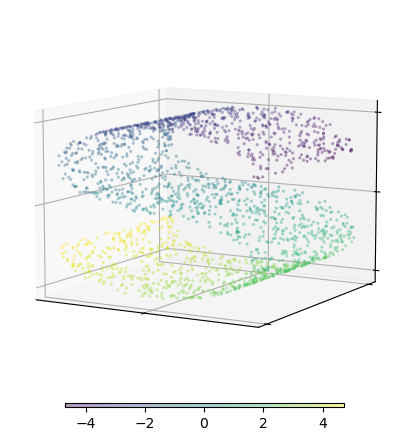

In [3]:
n = 2000

X, t = make_s_curve(n, random_state=42)
plot_3d(X, t, "")

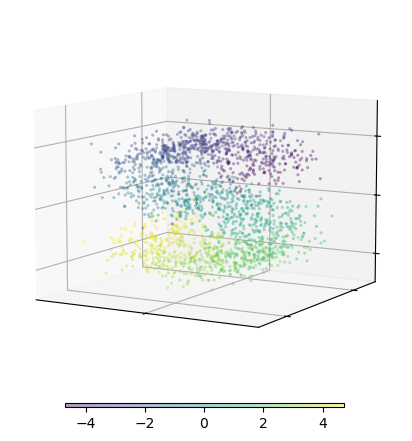

In [4]:
# Set seed for reproducibility
np.random.seed(42)

# Define noise level
noise_std = 0.25

# Add Gaussian noise to the position and velocity matrices
X_noisy = X + np.random.normal(scale=noise_std, size=X.shape)
plot_3d(X_noisy, t, "")

/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


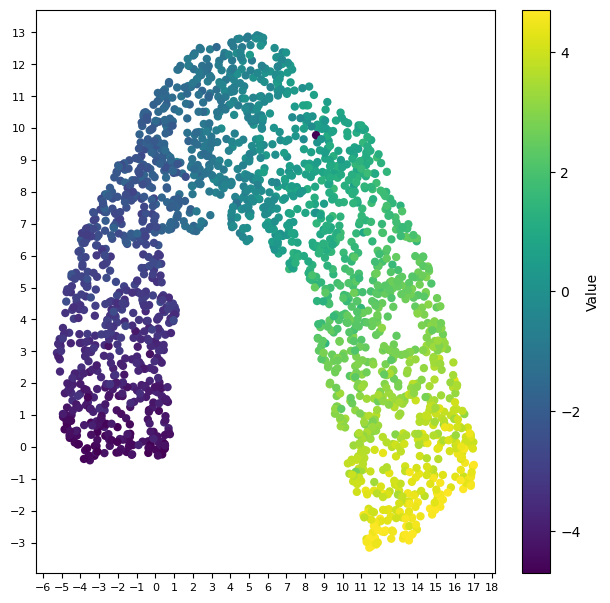

In [5]:
import umap

umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.5, n_components=2, random_state=42)
X_2d = umap_reducer.fit_transform(X_noisy)
plot_2d(X_2d, t, "")

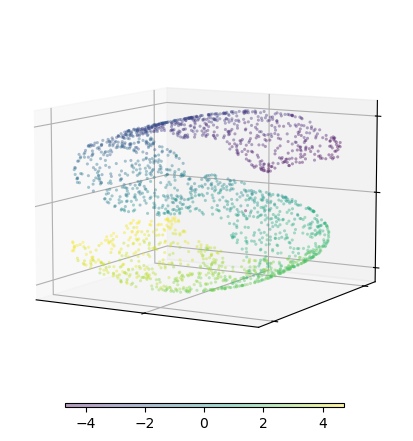

In [6]:
from flowmap_legacy.TPS import *

tps = ThinPlateSpline(X_2d, n_control_points=500)
tps.fit(X_noisy, dof_target=30)
X_smoothed = tps.predict(X_2d)
plot_3d(X_smoothed,t)

In [7]:
np.sum((X_noisy - X_smoothed) ** 2, axis=1)

array([0.013067  , 0.00937309, 0.03836318, ..., 0.02219687, 0.10542121,
       0.11586661], shape=(2000,))

In [8]:
np.exp(-np.sum((X_noisy - X_smoothed) ** 2, axis=1) / 0.1)

array([0.87750733, 0.91052774, 0.68138224, ..., 0.80094043, 0.34846686,
       0.31390462], shape=(2000,))

In [9]:
X_emb = X_2d
density=None
smooth=None
n_neighbors=None
min_mass=None

# remove invalid cells
idx_valid = np.isfinite(X_emb.sum(1))
X_emb = X_emb[idx_valid]

# prepare grid
n_obs, n_dim = X_emb.shape
density = 1 if density is None else density
smooth = 0.5 if smooth is None else smooth

grs = []
for dim_i in range(n_dim):
    m, M = np.min(X_emb[:, dim_i]), np.max(X_emb[:, dim_i])
    m = m - 0.01 * np.abs(M - m)
    M = M + 0.01 * np.abs(M - m)
    gr = np.linspace(m, M, int(50 * density))
    grs.append(gr)

meshes_tuple = np.meshgrid(*grs)
X_grid = np.vstack([i.flat for i in meshes_tuple]).T

# estimate grid velocities
if n_neighbors is None:
    n_neighbors = int(n_obs / 30)
nn = NearestNeighbors(n_neighbors=n_neighbors, n_jobs=-1)
nn.fit(X_emb)
dists, neighs = nn.kneighbors(X_grid)

scale = np.mean([(g[1] - g[0]) for g in grs]) * smooth
weight = normal.pdf(x=dists, scale=scale)
p_mass = weight.sum(1)

if min_mass is None:
    min_mass = 1
min_mass *= np.percentile(p_mass, 99) / 100
# X_grid = X_grid[p_mass > min_mass]

In [10]:
from scipy.spatial.distance import cdist
from scipy.spatial import KDTree

k=2
tree = KDTree(X_2d)
dists, _ = tree.query(X_2d, k=k+1)  # k+1 because the first neighbor is the point itself
avg_dist = np.mean(dists[:, 1:])  # Ignore the 0th distance (self-distance)
avg_dist

np.float64(0.18586699897329592)

In [11]:
sigma = avg_dist
f_values = np.exp(-np.sum((X_noisy - X_smoothed) ** 2, axis=1) / 0.1)

# Compute pairwise squared distances
dists = cdist(X_grid, X_2d, metric='sqeuclidean')

# Compute Gaussian weights
weights = np.exp(-dists / (2 * sigma**2))

# Normalize weights
weights /= np.sum(weights, axis=1, keepdims=True) + 1e-8  # Avoid division by zero

# Compute smoothed values using weighted average
smoothed_values = np.dot(weights, f_values)

(array([934.,  34.,  22.,  24.,  19.,  30.,  31.,  35.,  31.,  36.,  54.,
         53.,  66.,  70.,  74.,  82.,  94.,  93., 101.,  85.,  75.,  86.,
         88.,  75.,  71.,  47.,  46.,  23.,  12.,   9.]),
 array([6.46644764e-266, 3.21021473e-002, 6.42042945e-002, 9.63064418e-002,
        1.28408589e-001, 1.60510736e-001, 1.92612884e-001, 2.24715031e-001,
        2.56817178e-001, 2.88919325e-001, 3.21021473e-001, 3.53123620e-001,
        3.85225767e-001, 4.17327914e-001, 4.49430062e-001, 4.81532209e-001,
        5.13634356e-001, 5.45736503e-001, 5.77838651e-001, 6.09940798e-001,
        6.42042945e-001, 6.74145093e-001, 7.06247240e-001, 7.38349387e-001,
        7.70451534e-001, 8.02553682e-001, 8.34655829e-001, 8.66757976e-001,
        8.98860123e-001, 9.30962271e-001, 9.63064418e-001]),
 <BarContainer object of 30 artists>)

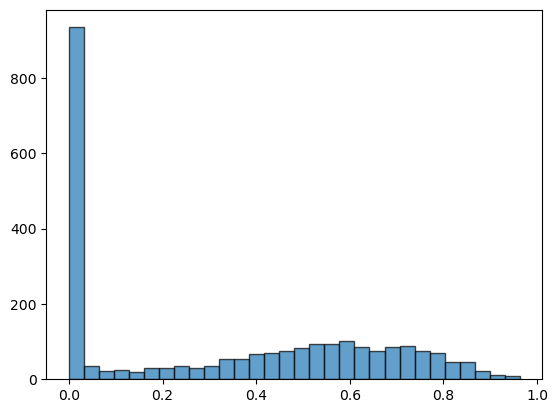

In [12]:
plt.hist(smoothed_values, bins=30, edgecolor='black', alpha=0.7)

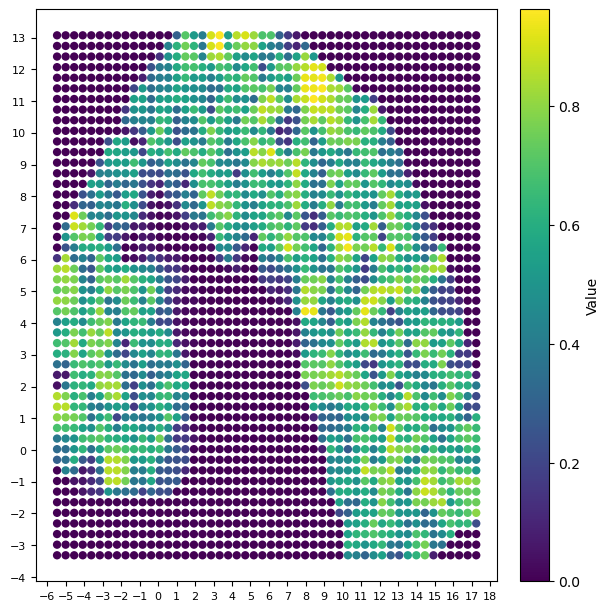

In [13]:
fig, ax = plt.subplots(figsize=(6, 6), facecolor="white", constrained_layout=True)
ax.tick_params(axis='both', which='major', labelsize=8)  # Adjust tick label size

# Add scatter plot
add_2d_scatter(ax, X_grid, points_color=smoothed_values)

# Set axis ticks
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from flowmap_legacy.TPS import ThinPlateSpline

# Define the range of degrees of freedom to test in log space
dof_targets = np.logspace(np.log10(20), np.log10(410), 11)  # Logarithmically spaced values

# Store the computed metrics
rmse_values = []
r2_values = []
gcv_values = []
rmse_gt_values = []

# Create TPS model
n_control_points = 1000  # Adjust as needed
tps = ThinPlateSpline(X_2d, n_control_points=n_control_points)

# Iterate over different degrees of freedom
for dof_target in dof_targets:
    print(f"Running with dof: {dof_target:.2f}")
    tps.fit(X_noisy, dof_target=dof_target)
    metrics = tps.evaluate_fit(X_noisy)
    
    # Compute RMSE with ground truth
    X_smoothed = tps.predict(X_2d)
    RSS_gt = np.sum((X - X_smoothed) ** 2)
    RMSE_gt = np.sqrt(RSS_gt / (X.shape[0] * X.shape[1]))

    # Store metrics
    rmse_values.append(metrics["RMSE"])
    r2_values.append(metrics["R2"])
    gcv_values.append(metrics["GCV"])
    rmse_gt_values.append(RMSE_gt)

Running with dof: 20.00


Running with dof: 27.05


Running with dof: 36.59


Running with dof: 49.49


Running with dof: 66.95


...

Running with dof: 122.48


Running with dof: 165.68


Running with dof: 224.10


Running with dof: 303.12


Running with dof: 410.00


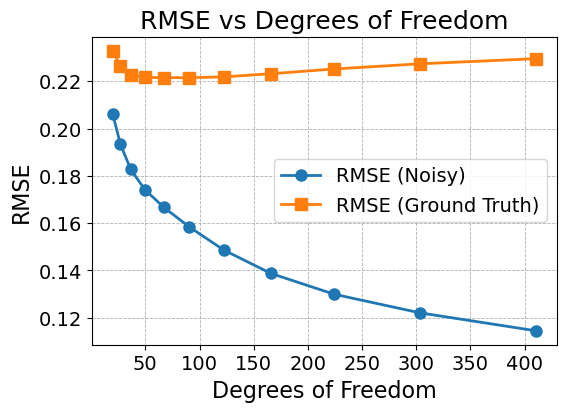

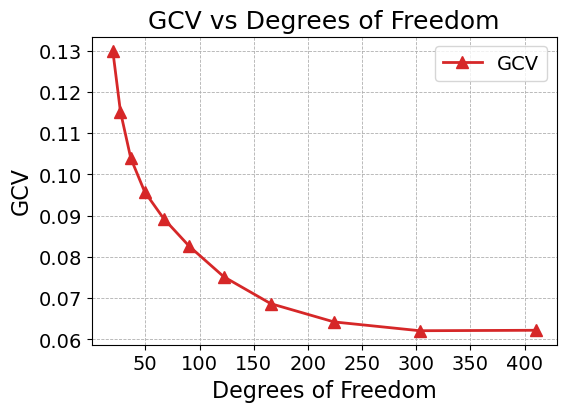

In [15]:
# Adjust text sizes for manuscript-quality plots
plt.figure(figsize=(6, 4))
plt.plot(dof_targets, rmse_values, label="RMSE (Noisy)", marker="o", markersize=8, linewidth=2)
plt.plot(dof_targets, rmse_gt_values, label="RMSE (Ground Truth)", marker="s", markersize=8, linewidth=2)
plt.xlabel("Degrees of Freedom", fontsize=16)
plt.ylabel("RMSE", fontsize=16)
plt.legend(fontsize=14)
plt.title("RMSE vs Degrees of Freedom", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle="--", linewidth=0.6)
plt.show()

# Create separate GCV plot with larger text
plt.figure(figsize=(6, 4))
plt.plot(dof_targets, gcv_values, label="GCV", marker="^", color="tab:red", markersize=8, linewidth=2)
plt.xlabel("Degrees of Freedom", fontsize=16)
plt.ylabel("GCV", fontsize=16)
plt.legend(fontsize=14)
plt.title("GCV vs Degrees of Freedom", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle="--", linewidth=0.6)
plt.show()


Running with dof: 20.00


Running with dof: 27.05


Running with dof: 36.59


Running with dof: 49.49


Running with dof: 66.95


...

Running with dof: 122.48


Running with dof: 165.68


Running with dof: 224.10


Running with dof: 303.12


Running with dof: 410.00


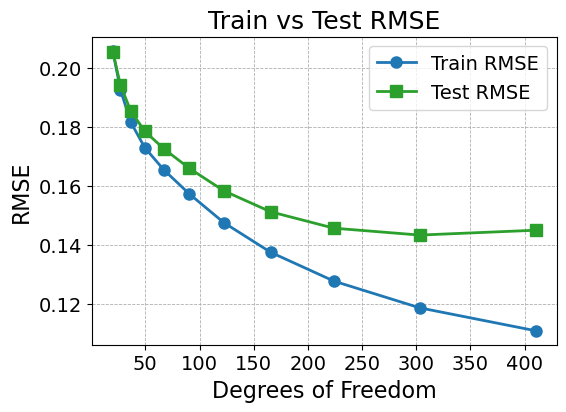

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from flowmap_legacy.TPS import ThinPlateSpline
from sklearn.model_selection import train_test_split

# Define the range of degrees of freedom to test in log space
dof_targets = np.logspace(np.log10(20), np.log10(410), 11)  # Logarithmically spaced values
# Store the computed metrics
rmse_train_values = []
rmse_test_values = []
# Split X_2d into training and testing sets
train_indices, test_indices = train_test_split(np.arange(len(X_2d)), test_size=0.2, random_state=42)
X_train, X_test = X_2d[train_indices], X_2d[test_indices]


# Create TPS model
n_control_points = 500  # Adjust as needed
tps = ThinPlateSpline(X_train, n_control_points=n_control_points)

# Iterate over different degrees of freedom
for dof_target in dof_targets:
    print(f"Running with dof: {dof_target:.2f}")
    tps.fit(X_noisy[train_indices,], dof_target=dof_target)
    
    # Compute RMSE for training and testing sets
    X_train_smoothed = tps.predict(X_train)
    X_test_smoothed = tps.predict(X_test)
    
    RMSE_train = np.sqrt(np.mean((X_noisy[train_indices,] - X_train_smoothed) ** 2))
    RMSE_test = np.sqrt(np.mean((X_noisy[test_indices,] - X_test_smoothed) ** 2))
    
    # Store metrics
    rmse_train_values.append(RMSE_train)
    rmse_test_values.append(RMSE_test)

# Create RMSE plot for train and test
plt.figure(figsize=(6, 4))
plt.plot(dof_targets, rmse_train_values, label="Train RMSE", marker="o", color="tab:blue", markersize=8, linewidth=2)
plt.plot(dof_targets, rmse_test_values, label="Test RMSE", marker="s", color="tab:green", markersize=8, linewidth=2)

# Formatting
plt.xlabel("Degrees of Freedom", fontsize=16)
plt.ylabel("RMSE", fontsize=16)
plt.legend(fontsize=14)
plt.title("Train vs Test RMSE", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle="--", linewidth=0.6)
plt.show()

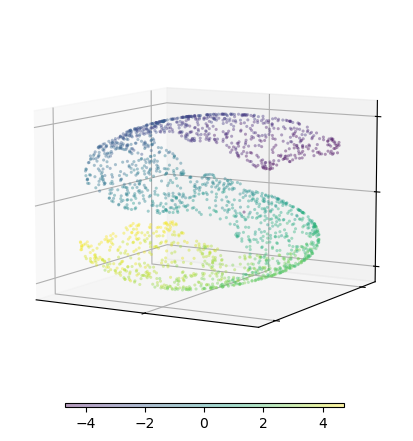

In [17]:
tps = ThinPlateSpline(X_2d, n_control_points=n_control_points)
tps.fit(X_noisy, dof_target=20)
X_smoothed = tps.predict(X_2d)
plot_3d(X_smoothed,t)

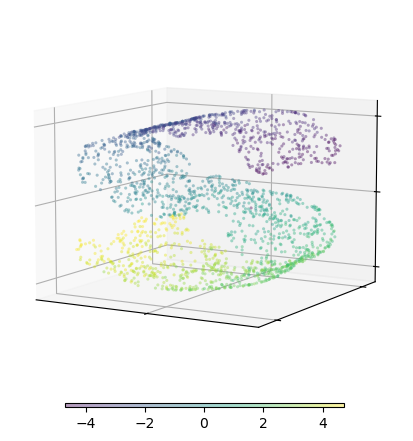

In [18]:
tps = ThinPlateSpline(X_2d, n_control_points=n_control_points)
tps.fit(X_noisy, dof_target=50)
X_smoothed = tps.predict(X_2d)
plot_3d(X_smoothed,t)

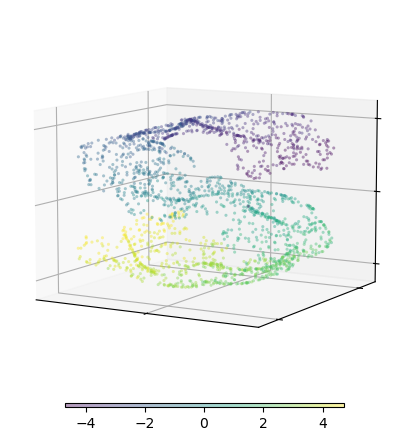

In [19]:
tps = ThinPlateSpline(X_2d, n_control_points=n_control_points)
tps.fit(X_noisy, dof_target=100)
X_smoothed = tps.predict(X_2d)
plot_3d(X_smoothed,t)

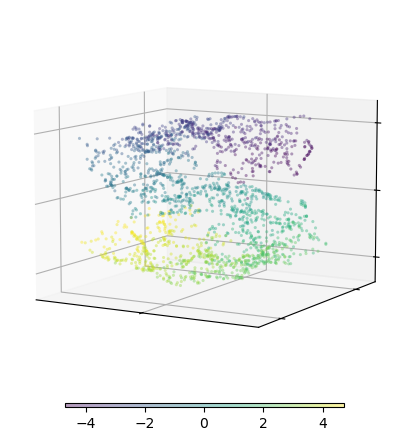

In [20]:
tps = ThinPlateSpline(X_2d, n_control_points=n_control_points)
tps.fit(X_noisy, dof_target=400)
X_smoothed = tps.predict(X_2d)
plot_3d(X_smoothed,t)